# LightGBM

In [34]:
import pandas as pd

df = pd.read_csv('../data/ds_salaries.csv')

## データ前処理

In [35]:
# 不要列削除
df = df.drop(columns=["salary", 'salary_currency'])

# 説明変数と目的変数の分離
X = df.drop("salary_in_usd", axis=1)
y = df["salary_in_usd"]

In [36]:
# train_test分割
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [37]:
# 少数カテゴリをOtherに変換
import numpy as np

target_columns = ['job_title', 'employee_residence', 'company_location']
for target_column in target_columns:
    counts = X_train[target_column].value_counts()
    majors = counts[counts >= 30].index
    
    X_train[target_column + '_mod'] = np.where(
        X_train[target_column].isin(majors), 
        X_train[target_column], 
        'Other', 
    )
    
    X_test[target_column + '_mod'] = np.where(
        X_test[target_column].isin(majors), 
        X_test[target_column], 
        'Other', 
    )

# 不要列削除
X_train = X_train.drop(columns=['job_title', 'employee_residence', 'company_location'])
X_test = X_test.drop(columns=['job_title', 'employee_residence', 'company_location'])

In [38]:
# カテゴリ型に変換
cat_cols = [
    'experience_level',
    'employment_type',
    'job_title_mod',
    'employee_residence_mod',
    'company_location_mod', 
    'company_size'
]

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    # X_trainのカテゴリ定義を用いてX_testをカテゴリ型に変換
    X_test[col] = pd.Categorical(
        X_test[col], 
        categories=X_train[col].cat.categories
    )

# 列を揃える
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

## バリデーション設計

### クロスバリデーション

In [39]:
# ML用
from sklearn.model_selection import KFold

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(X_train))

for nfold, (train_index, valid_index) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    X_train_fold = X_train.iloc[train_index]
    y_train_fold = y_train.iloc[train_index]
    
    X_valid_fold = X_train.iloc[valid_index]
    y_valid_fold = y_train.iloc[valid_index]
    
    print(X_train_fold.shape, y_train_fold.shape)
    print(X_valid_fold.shape, y_valid_fold.shape)
    print(f'y_train : {y_train.mean()}, y_train_fold : {y_train_fold.mean()}, y_valid_fold : {y_valid_fold.mean()}')

-------------------- 0 --------------------
(2403, 8) (2403,)
(601, 8) (601,)
y_train : 138580.20539280958, y_train_fold : 138685.56346233873, y_valid_fold : 138158.94841930116
-------------------- 1 --------------------
(2403, 8) (2403,)
(601, 8) (601,)
y_train : 138580.20539280958, y_train_fold : 138513.01872659175, y_valid_fold : 138848.84026622295
-------------------- 2 --------------------
(2403, 8) (2403,)
(601, 8) (601,)
y_train : 138580.20539280958, y_train_fold : 137816.09696213066, y_valid_fold : 141635.3677204659
-------------------- 3 --------------------
(2403, 8) (2403,)
(601, 8) (601,)
y_train : 138580.20539280958, y_train_fold : 139056.01872659175, y_valid_fold : 136677.74376039935
-------------------- 4 --------------------
(2404, 8) (2404,)
(600, 8) (600,)
y_train : 138580.20539280958, y_train_fold : 138830.22504159732, y_valid_fold : 137578.46


## モデル学習

In [40]:
import numpy as np
from sklearn.model_selection import KFold
import lightgbm as lgb
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(X_train))
scores = []
model_list = []

for nfold, (train_index, valid_index) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    X_train_fold = X_train.iloc[train_index]
    y_train_fold = y_train.iloc[train_index]
    
    X_valid_fold = X_train.iloc[valid_index]
    y_valid_fold = y_train.iloc[valid_index]

    model_lgb = lgb.LGBMRegressor(
        objective='regression',
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        random_state=123
    )

    model_lgb.fit(
        X_train_fold,
        y_train_fold,
        eval_set=[(X_valid_fold, y_valid_fold)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(50), 
            lgb.log_evaluation(100)
        ]
    )

    pred = model_lgb.predict(X_valid_fold)

    r2 = r2_score(y_valid_fold, pred)
    rmse = np.sqrt(mean_squared_error(y_valid_fold, pred))
    print('R2 :', r2)
    print('RMSE :', rmse)

    scores.append({'fold': nfold, 'R2': r2, 'RMSE': rmse})
    model_list.append(model_lgb)

print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('\nCV mean')
print(score_df[['R2', 'RMSE']].mean())

-------------------- 0 --------------------
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015922 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 48
[LightGBM] [Info] Number of data points in the train set: 2403, number of used features: 8
[LightGBM] [Info] Start training from score 138685.563462
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 51071.7	valid_0's l2: 2.60832e+09
[200]	valid_0's rmse: 50690.8	valid_0's l2: 2.56956e+09
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[300]	valid_0's rmse: 50559.1	valid_0's l2: 2.55622e+09
Early stopping, best iteration is:
[252]	valid_0's rmse: 50536.6	valid_0's l2: 2.55394e+09
R2 : 0.3641447474644499
RMSE : 50536.55907177296
-------------------- 1 --------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000355 seconds.
You can set `force_ro

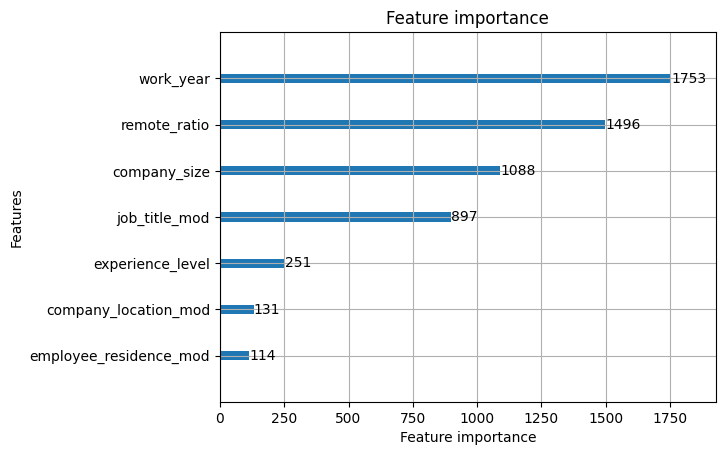

In [41]:
import matplotlib.pyplot as plt

lgb.plot_importance(model_lgb)
plt.show()

In [42]:
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': model_lgb.feature_importances_})
feature_importance_df.sort_values('importance', ascending=False, ignore_index=True)

,feature,importance
0,work_year,1753
1,remote_ratio,1496
2,company_size,1088
3,job_title_mod,897
4,experience_level,251
5,company_location_mod,131
6,employee_residence_mod,114
7,employment_type,0


/Users/takahashishinji/portfolio/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


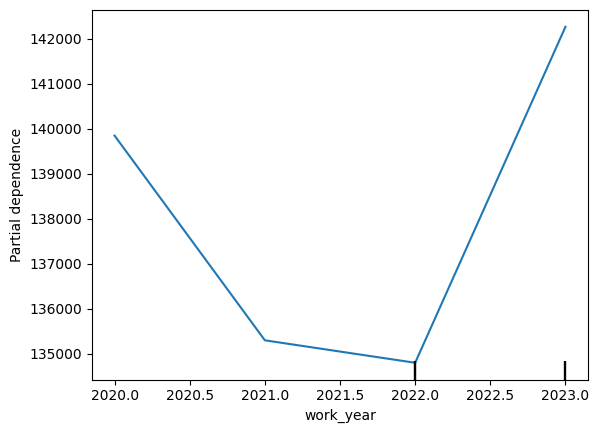

In [43]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    model_lgb,
    X_train,
    ['work_year']
)

/Users/takahashishinji/portfolio/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


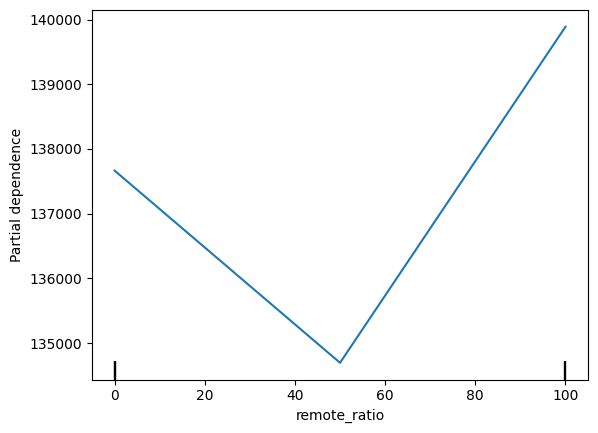

In [44]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    model_lgb,
    X_train,
    ['remote_ratio']
)

## モデル推論

In [45]:
preds = []

for model in model_list:
    pred = model.predict(X_test)
    preds.append(pred)
    
preds_array = np.array(preds)
y_test_pred = np.mean(preds_array, axis=0)

r2 = r2_score(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("R2 :", r2)
print("RMSE :", rmse)

R2 : 0.44935501058101246
RMSE : 44618.92281187468
